# Addressing peer reviews

In this notebook we will use code to answer to the reviews obtained by the peer-review system.

## Retrieving best model
First we need to retrieve the best model to be able to get the accuracy per barcode and check the attention weights.

In [2]:
import numpy as np
import os
import pandas as pd
import tensorflow as tf

2025-04-07 17:17:21.598671: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-07 17:17:22.316034: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


After running ShowAccuracy.py on the GPU with our container we get this output:

../../results/NewNN/Ablation/20240503_11-42-14_FinalLR1E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.030026549473404884, 0.9913243651390076]
Validation  : [0.03592557832598686, 0.986358106136322]
Test : [0.19601191580295563, 0.954965353012085]
../../results/NewNN/Ablation/20240503_11-43-30_FinalLR1E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.04372193291783333, 0.9863389134407043]
Validation  : [0.057527847588062286, 0.9811205863952637]
Test : [0.1767975389957428, 0.956986129283905]
../../results/NewNN/Ablation/20240503_11-43-50_FinalLR1E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.04334758222103119, 0.9871123433113098]
Validation  : [0.0533052459359169, 0.9833130240440369]
Test : [0.18823425471782684, 0.956986129283905]
../../results/NewNN/Ablation/20240503_11-51-02_FinalLR2E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.029812674969434738, 0.9897401928901672]
Validation  : [0.04180384799838066, 0.9873325228691101]
Test : [0.1808346062898636, 0.957274854183197]
../../results/NewNN/Ablation/20240503_12-05-49_FinalLR2E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.022611744701862335, 0.9937751889228821]
Validation  : [0.025851359590888023, 0.9912301898002625]
Test : [0.2196020483970642, 0.9546766877174377]
../../results/NewNN/Ablation/20240503_13-10-14_FinalLR2E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.03708413988351822, 0.9883796572685242]
Validation  : [0.04767124727368355, 0.985018253326416]
Test : [0.18380998075008392, 0.9584295749664307]
../../results/NewNN/Ablation/20240503_16-13-15_FinalLR5E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.028121011331677437, 0.9919300675392151]
Validation  : [0.03644905611872673, 0.9890377521514893]
Test : [0.19330722093582153, 0.9578521847724915]
../../results/NewNN/Ablation/20240506_14-50-01_FinalLR2E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.038283731788396835, 0.9875223636627197]
Validation  : [0.046881433576345444, 0.9848964810371399]
Test : [0.20399388670921326, 0.954965353012085]

Therefore, the file that contains our best model is actually  ../../results/NewNN/Ablation/20240503_13-10-14_FinalLR2E4_BestModel.keras with a test accuracy of 0.9584295749664307. We will use this model to compute the accuracies of each barcode

## Finding per barcode accuracy
With the best model, we predict the labels with the script observing....py. The results are saved in the results section and here we compare:

In [11]:
y_est=np.load("../../results/PeerReview/y_est.npy")
y_true_onehot=np.load("../../results/PeerReview/y_true.npy") #One hot encoding
y_true=np.argwhere(y_true_onehot==1)[:,1] #reformat
print(np.sum(y_true==y_est)/len(y_true)) #We observe the mentioned accuracy.

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [19]:
n_labels=8; #8 barcodes.
conf_matrix=np.zeros((n_labels,n_labels))
for true_barcode in range(n_labels):
    predictions=y_est[y_true==true_barcode]; #For this barcode gets the predictions
    for pred_barcode in range(n_labels):
        conf_matrix[true_barcode,pred_barcode] = np.sum(predictions==pred_barcode)/len(predictions);

In [20]:
conf_matrix

array([[0.95652174, 0.02766798, 0.01185771, 0.        , 0.00395257,
        0.        , 0.        , 0.        ],
       [0.00398406, 0.94223108, 0.        , 0.0438247 , 0.00398406,
        0.0059761 , 0.        , 0.        ],
       [0.03960396, 0.        , 0.92079208, 0.02970297, 0.00990099,
        0.        , 0.        , 0.        ],
       [0.00241838, 0.01813785, 0.00967352, 0.95042322, 0.        ,
        0.        , 0.00725514, 0.0120919 ],
       [0.06024096, 0.03614458, 0.        , 0.01204819, 0.8313253 ,
        0.        , 0.03614458, 0.02409639],
       [0.        , 0.00468384, 0.        , 0.00702576, 0.        ,
        0.98126464, 0.00234192, 0.00468384],
       [0.00330033, 0.        , 0.00330033, 0.0049505 , 0.01815182,
        0.0049505 , 0.95214521, 0.01320132],
       [0.        , 0.00150376, 0.        , 0.00451128, 0.        ,
        0.        , 0.        , 0.99398496]])

NameError: name 'itertools' is not defined

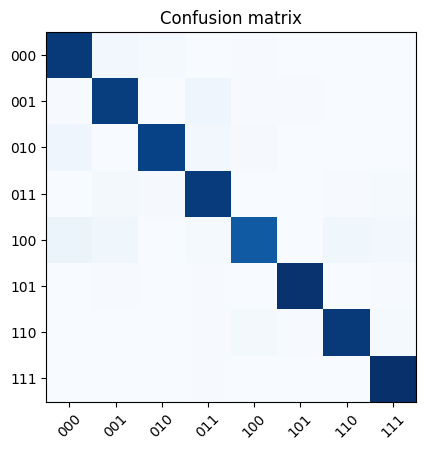

In [32]:
## We will use this function from QuipuNet to obtain the same formatting!
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues): 
    "This function prints and plots the confusion matrix."
    #cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    #pyplot.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' 
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Barcode')
    plt.xlabel('Predicted Barcode')
disp = ConfusionMatrixDisplay(conf_matrix)
barcodeLabels= ['000','001','010','011','100','101','110','111']
plot_confusion_matrix(conf_matrix, classes=barcodeLabels, title="Confusion matrix")
